# Práctica - Clase 4: Aprendizaje Automático

## Actividad 2 (v2.0): Regresión Logística — Análisis Extendido

**Objetivo:** predecir qué sistema operativo usa un visitante de un sitio web (0 = Windows, 1 = Macintosh, 2 = Linux) a partir de 4 características tomadas de Google Analytics:

- `duracion`: duración de la visita en segundos
- `paginas`: cantidad de páginas vistas durante la sesión
- `acciones`: cantidad de acciones del usuario (clics, scroll, checkbox, sliders, etc.)
- `valor`: suma del valor de las acciones (cada acción tiene una valoración de importancia)

> **Nota:** Este cuaderno extiende la version base (`Regresion_logistica.ipynb`) incorporando un modelo baseline, ajuste de hiperparametros, interpretacion de coeficientes, mapa de correlaciones, matriz normalizada y una funcion reutilizable de prediccion.

### 1. Importacion de librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import linear_model
from sklearn import model_selection
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
from sklearn.dummy import DummyClassifier

sns.set_theme(style="whitegrid")

### 2. Carga de Datos y AED

In [2]:
df = pd.read_csv("../datos/usuarios_win_mac_lin.csv")
print("Filas y columnas:", df.shape)
display(df.head())

print("Valores nulos por columna:")
display(df.isnull().sum())

display(df.describe())

print("Filas duplicadas:", df.duplicated().sum())

Filas y columnas: (170, 5)


,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


Valores nulos por columna:


duracion    0
paginas     0
acciones    0
valor       0
clase       0
dtype: int64

,duracion,paginas,acciones,valor,clase
count,170.000000,170.000000,170.000000,170.000000,170.000000
mean,111.075729,2.041176,8.723529,32.676471,0.752941
std,202.453200,1.500911,9.136054,44.751993,0.841327
min,1.000000,1.000000,1.000000,1.000000,0.000000
25%,11.000000,1.000000,3.000000,8.000000,0.000000
50%,13.000000,2.000000,6.000000,20.000000,0.000000
75%,108.000000,2.000000,10.000000,36.000000,2.000000
max,898.000000,9.000000,63.000000,378.000000,2.000000


Filas duplicadas: 16


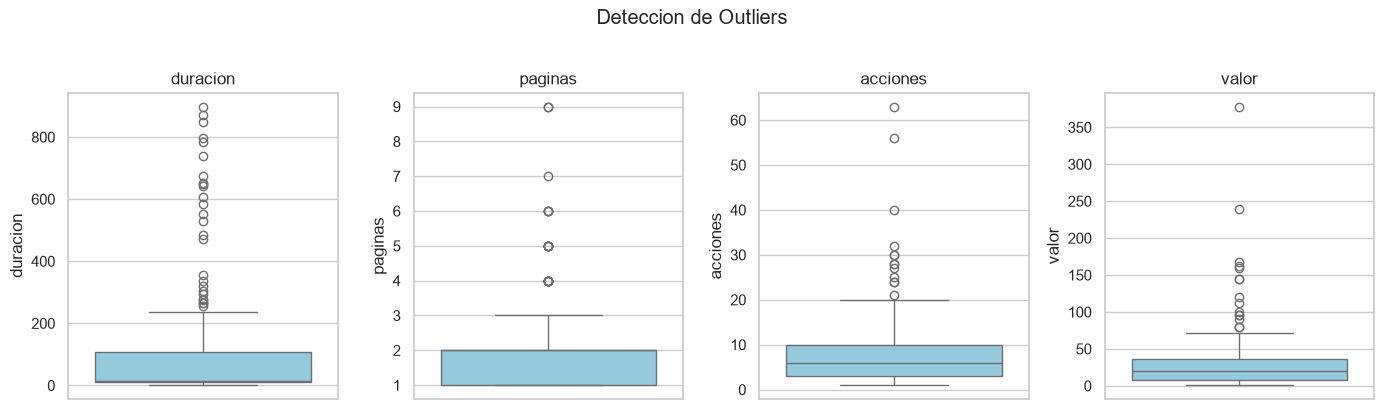

In [3]:
# Boxplots por variable
variables = ["duracion", "paginas", "acciones", "valor"]
fig, ejes = plt.subplots(1, 4, figsize=(14, 4))
for eje, var in zip(ejes, variables):
    sns.boxplot(y=df[var], ax=eje, color="skyblue")
    eje.set_title(var)
plt.suptitle("Deteccion de Outliers", y=1.02)
plt.tight_layout()
plt.show()

In [4]:
# Respaldo estadistico de los boxplots
for var in variables:
    q1 = df[var].quantile(0.25)
    q3 = df[var].quantile(0.75)
    iqr = q3 - q1
    lim_sup = q3 + 1.5 * iqr
    outliers = df[df[var] > lim_sup]
    print(f"--- {var} ---")
    print(f"  Min: {df[var].min():.1f}  |  Q1: {q1:.1f}  |  Mediana: {df[var].median():.1f}  |  Q3: {q3:.1f}  |  Max: {df[var].max():.1f}")
    print(f"  IQR: {iqr:.1f}  |  Limite superior: {lim_sup:.1f}")
    print(f"  Outliers: {len(outliers)} de {len(df)} ({len(outliers)/len(df)*100:.1f}%)")
    print()

--- duracion ---
  Min: 1.0  |  Q1: 11.0  |  Mediana: 13.0  |  Q3: 108.0  |  Max: 898.0
  IQR: 97.0  |  Limite superior: 253.5
  Outliers: 26 de 170 (15.3%)

--- paginas ---
  Min: 1.0  |  Q1: 1.0  |  Mediana: 2.0  |  Q3: 2.0  |  Max: 9.0
  IQR: 1.0  |  Limite superior: 3.5
  Outliers: 24 de 170 (14.1%)

--- acciones ---
  Min: 1.0  |  Q1: 3.0  |  Mediana: 6.0  |  Q3: 10.0  |  Max: 63.0
  IQR: 7.0  |  Limite superior: 20.5
  Outliers: 13 de 170 (7.6%)

--- valor ---
  Min: 1.0  |  Q1: 8.0  |  Mediana: 20.0  |  Q3: 36.0  |  Max: 378.0
  IQR: 28.0  |  Limite superior: 78.0
  Outliers: 15 de 170 (8.8%)



#### Mapa de correlaciones entre variables
Verificamos si hay variables muy relacionadas entre si, lo cual podria dificultar al modelo separar su efecto individual.

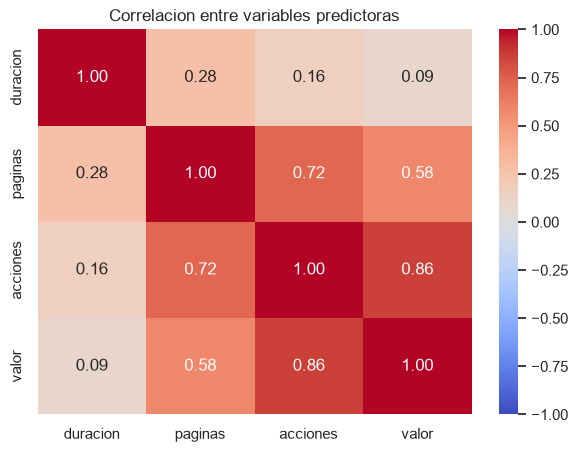

Pares con correlacion > 0.7:
  paginas vs acciones: 0.724
  acciones vs valor: 0.863


In [5]:
# Heatmap de correlacion con valores numericos
plt.figure(figsize=(7, 5))
corr = df[variables].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlacion entre variables predictoras")
plt.show()

# Destacar pares con alta correlacion
print("Pares con correlacion > 0.7:")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.7:
            print(f"  {corr.columns[i]} vs {corr.columns[j]}: {corr.iloc[i, j]:.3f}")

Como se esperaba, `acciones` y `valor` estan fuertemente correlacionadas: el valor de una visita depende directamente de cuantas acciones realizo el usuario. Esto significa que ambas variables aportan informacion redundante, lo cual puede dificultar que el modelo separe su efecto individual sobre la clasificacion.

clase
Windows      86
Linux        44
Macintosh    40
Name: count, dtype: int64


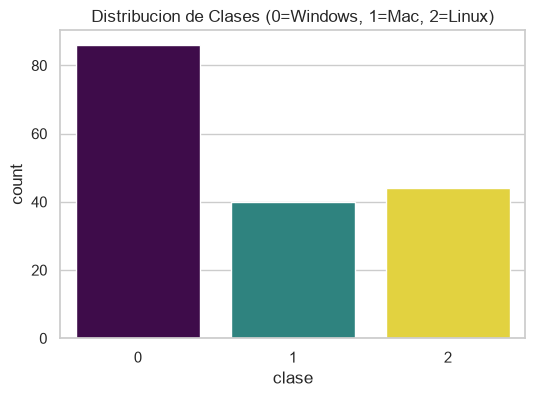

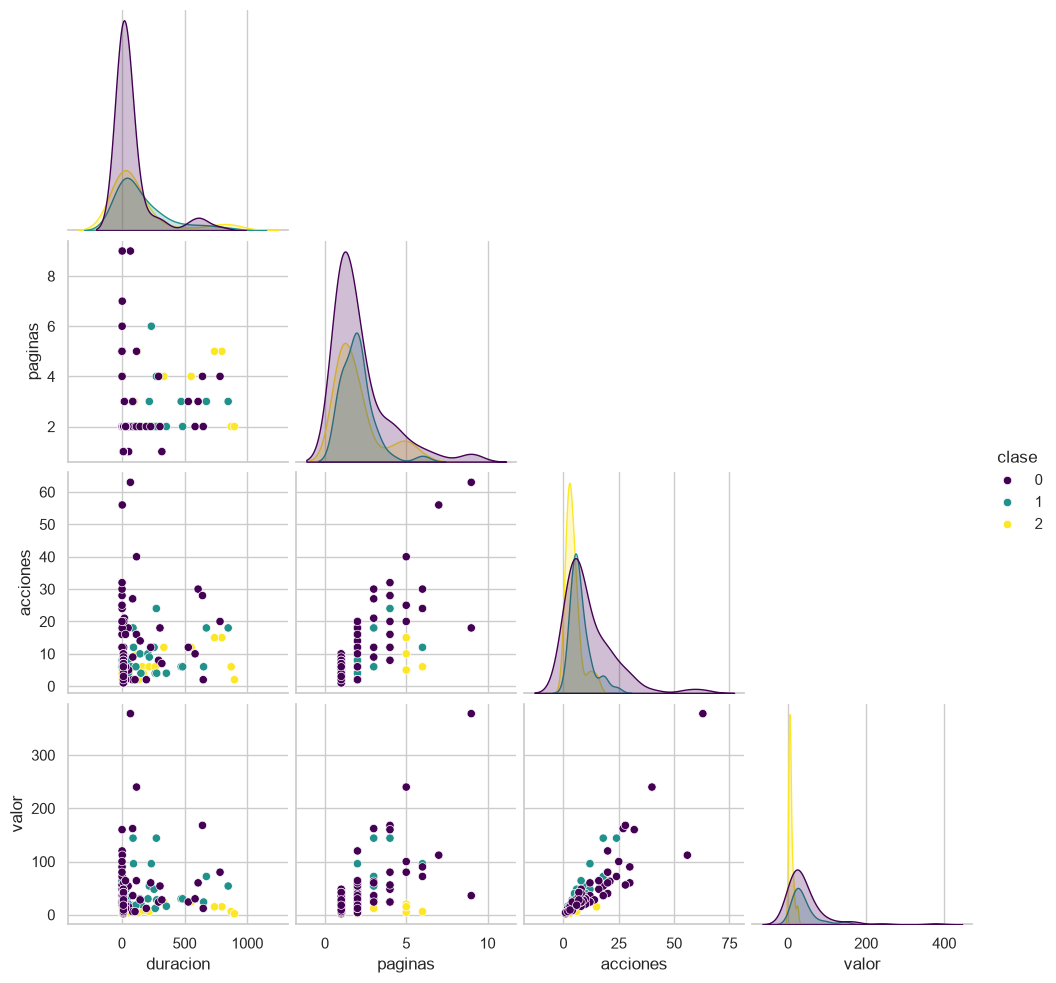

In [6]:
# Distribucion de clases
etiquetas = {0: "Windows", 1: "Macintosh", 2: "Linux"}
print(df["clase"].map(etiquetas).value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="clase", hue="clase", palette="viridis", legend=False)
plt.title("Distribucion de Clases (0=Windows, 1=Mac, 2=Linux)")
plt.show()

sns.pairplot(df, hue="clase", palette="viridis", corner=True)
plt.show()

### 3. Preparacion de los Datos y Modelado

In [7]:
X = np.array(df.drop(["clase"], axis=1))
y = np.array(df["clase"])

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clasificador = linear_model.LogisticRegression(solver="lbfgs", max_iter=1000, class_weight="balanced")
clasificador.fit(X_train, y_train)

print(f"Precision en entrenamiento: {clasificador.score(X_train, y_train):.2f}")

Precision en entrenamiento: 0.68


#### Modelo de referencia (baseline)
Antes de evaluar nuestro modelo, comparamos contra un clasificador trivial que siempre predice la clase mas frecuente (Windows). Esto nos da el piso minimo que cualquier modelo real debe superar.

In [8]:
# Baseline: siempre predice la clase mas frecuente
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline = DummyClassifier(strategy="most_frequent")
cv_baseline = model_selection.cross_val_score(baseline, X, y, cv=skf)
print(f"Baseline (siempre Windows): {cv_baseline.mean():.2f} (+/- {cv_baseline.std():.2f})")

cv_modelo = model_selection.cross_val_score(clasificador, X, y, cv=skf)
print(f"Regresion Logistica:        {cv_modelo.mean():.2f} (+/- {cv_modelo.std():.2f})")

mejora = cv_modelo.mean() - cv_baseline.mean()
print(f"\nMejora sobre baseline: +{mejora:.2f} ({mejora/cv_baseline.mean()*100:.0f}% relativo)")

Baseline (siempre Windows): 0.51 (+/- 0.01)
Regresion Logistica:        0.71 (+/- 0.05)

Mejora sobre baseline: +0.21 (41% relativo)


### 4. Evaluacion de la Clasificacion

In [9]:
prediccion = clasificador.predict(X_test)
print(f"Precision general en datos de prueba: {accuracy_score(y_test, prediccion):.2f}\n")

print("Reporte de Clasificacion:")
print(classification_report(y_test, prediccion, target_names=["Windows", "Macintosh", "Linux"]))

Precision general en datos de prueba: 0.76

Reporte de Clasificacion:
              precision    recall  f1-score   support

     Windows       0.91      0.59      0.71        17
   Macintosh       0.78      0.88      0.82         8
       Linux       0.64      1.00      0.78         9

    accuracy                           0.76        34
   macro avg       0.78      0.82      0.77        34
weighted avg       0.81      0.76      0.76        34



#### Matriz de confusion normalizada
Con clases desbalanceadas, una matriz en porcentajes es mas facil de leer: cada fila suma 100% y muestra que proporcion de cada clase real fue clasificada correctamente.

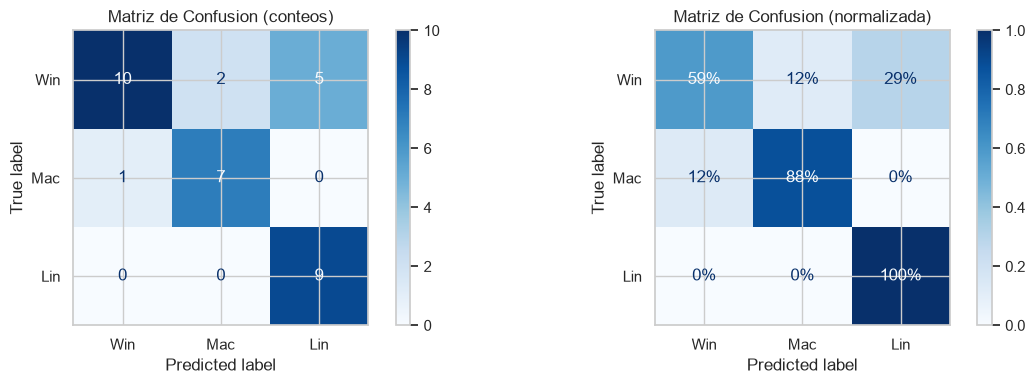

In [10]:
# Matriz de confusion normalizada (porcentajes por fila)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, prediccion, display_labels=["Win", "Mac", "Lin"],
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Matriz de Confusion (conteos)")

ConfusionMatrixDisplay.from_predictions(
    y_test, prediccion, display_labels=["Win", "Mac", "Lin"],
    normalize="true", cmap="Blues", values_format=".0%", ax=axes[1]
)
axes[1].set_title("Matriz de Confusion (normalizada)")

plt.tight_layout()
plt.show()

### 5. Ajuste del hiperparametro C (regularizacion)
En la regresion logistica, `C` controla la regularizacion: un C chico penaliza mas los coeficientes (equivale a un lambda grande en Ridge), y un C grande da mas libertad al modelo.

Probamos varios valores con `GridSearchCV` para encontrar el optimo.

,C,Precision media,Desviacion
0,0.001,0.676471,0.052613
1,0.010,0.694118,0.060563
2,0.100,0.711765,0.057032
3,1.000,0.711765,0.050602
4,10.000,0.711765,0.050602
5,100.000,0.711765,0.050602
6,1000.000,0.711765,0.050602



Mejor C: 0.1
Mejor precision: 0.7118


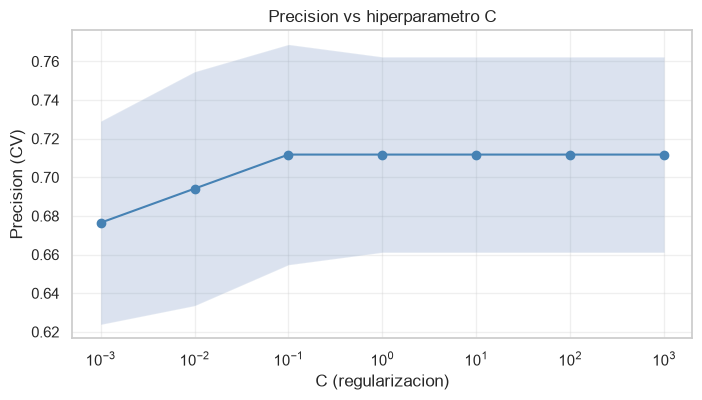

In [11]:
# Busqueda del mejor C
param_grid = {"C": [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
grid = GridSearchCV(
    linear_model.LogisticRegression(solver="lbfgs", max_iter=1000, class_weight="balanced"),
    param_grid, cv=skf, scoring="accuracy"
)
grid.fit(X, y)

# Resultados
resultados = pd.DataFrame(grid.cv_results_)[["param_C", "mean_test_score", "std_test_score"]]
resultados.columns = ["C", "Precision media", "Desviacion"]
display(resultados)

print(f"\nMejor C: {grid.best_params_['C']}")
print(f"Mejor precision: {grid.best_score_:.4f}")

# Grafico
plt.figure(figsize=(8, 4))
plt.semilogx(resultados["C"], resultados["Precision media"], "o-", color="steelblue")
plt.fill_between(
    resultados["C"],
    resultados["Precision media"] - resultados["Desviacion"],
    resultados["Precision media"] + resultados["Desviacion"],
    alpha=0.2
)
plt.xlabel("C (regularizacion)")
plt.ylabel("Precision (CV)")
plt.title("Precision vs hiperparametro C")
plt.grid(True, alpha=0.3)
plt.show()

Si el mejor C difiere de 1.0, reentrenamos el modelo final con ese valor. Si no, confirmamos que el valor por defecto ya era optimo.

In [12]:
# Reentrenar con el mejor C
mejor_c = grid.best_params_["C"]
clasificador_final = linear_model.LogisticRegression(
    solver="lbfgs", max_iter=1000, class_weight="balanced", C=mejor_c
)
clasificador_final.fit(X_train, y_train)
print(f"Modelo final entrenado con C={mejor_c}")
print(f"Precision en test: {clasificador_final.score(X_test, y_test):.2f}")

Modelo final entrenado con C=0.1
Precision en test: 0.76


### 6. Interpretacion de coeficientes
La regresion logistica multiclase genera un vector de coeficientes por cada clase. Valores positivos altos indican que esa variable empuja la prediccion hacia esa clase.

Coeficientes por clase:


,duracion,paginas,acciones,valor
Windows,-0.0031,-0.2009,-0.1779,0.1969
Macintosh,-0.0000,0.0005,-0.4748,0.2348
Linux,0.0031,0.2004,0.6527,-0.4317


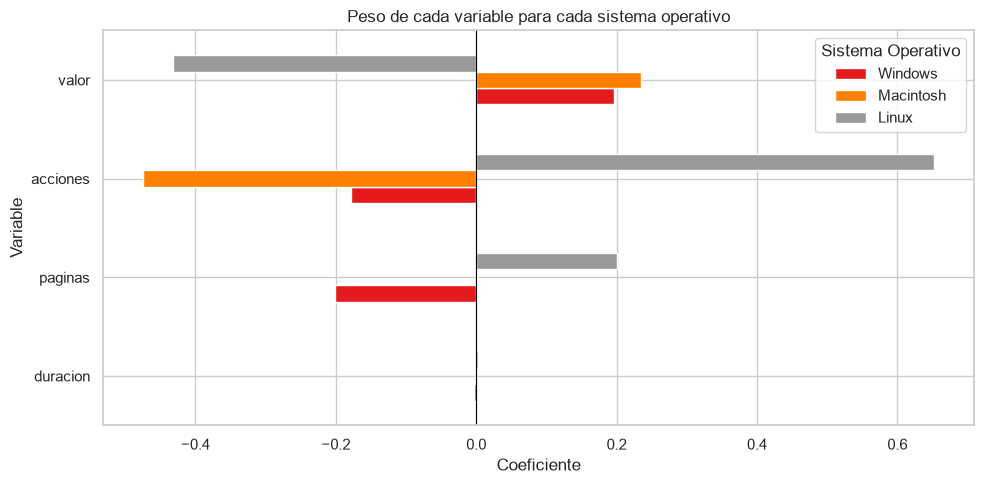

In [13]:
# Coeficientes del modelo final
nombres_vars = ["duracion", "paginas", "acciones", "valor"]
nombres_clases = ["Windows", "Macintosh", "Linux"]

coef_df = pd.DataFrame(
    clasificador_final.coef_,
    index=nombres_clases,
    columns=nombres_vars
)
print("Coeficientes por clase:")
display(coef_df.round(4))

# Grafico de barras agrupado
coef_df.T.plot(kind="barh", figsize=(10, 5), colormap="Set1")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.title("Peso de cada variable para cada sistema operativo")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.legend(title="Sistema Operativo")
plt.tight_layout()
plt.show()

**Que distingue a cada tipo de usuario:**
- Los coeficientes revelan que variables empujan la prediccion hacia cada sistema operativo.
- Comparando las barras se puede responder preguntas como: un usuario de Linux se caracteriza por visitas con pocas acciones y bajo valor? Un usuario de Mac tiende a visitas mas largas?
- La alta correlacion entre `acciones` y `valor` se refleja aqui: sus coeficientes tienden a compensarse mutuamente.

### 7. Fronteras de Decision (pcolormesh)
Modelo auxiliar con 2 variables (`duracion` y `acciones`) para poder visualizar las areas de decision en un plano 2D.

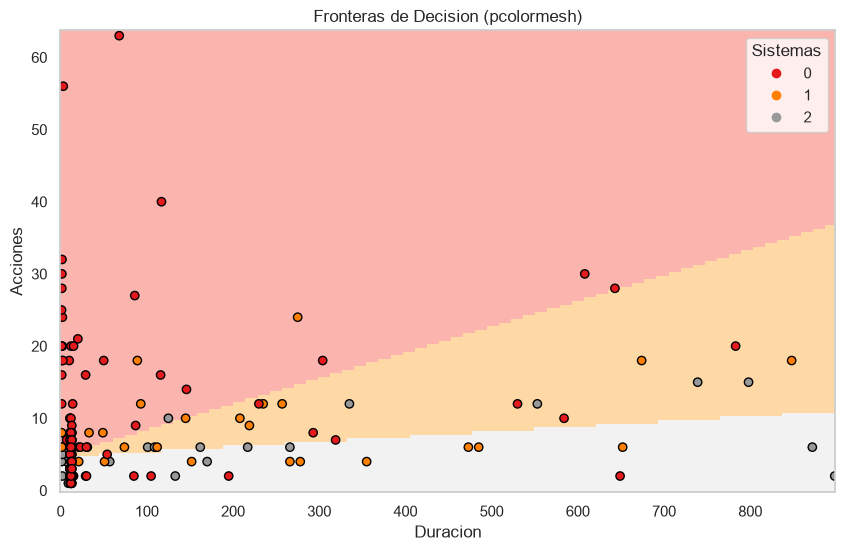

In [14]:
X_2d = df[["duracion", "acciones"]].values
y_2d = df["clase"].values

clasificador_2d = linear_model.LogisticRegression(
    solver="lbfgs", max_iter=1000, class_weight="balanced", C=mejor_c
)
clasificador_2d.fit(X_2d, y_2d)

x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
valor_x, valor_y = np.meshgrid(
    np.arange(x_min, x_max, 0.5),
    np.arange(y_min, y_max, 0.5)
)
malla = clasificador_2d.predict(np.c_[valor_x.ravel(), valor_y.ravel()]).reshape(valor_x.shape)

plt.figure(figsize=(10, 6))
plt.pcolormesh(valor_x, valor_y, malla, cmap=plt.cm.Pastel1, shading="auto")
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, edgecolors="black", cmap=plt.cm.Set1)
plt.title("Fronteras de Decision (pcolormesh)")
plt.xlabel("Duracion")
plt.ylabel("Acciones")
plt.legend(*scatter.legend_elements(), title="Sistemas")
plt.show()

### 8. Funcion de prediccion reutilizable
En lugar de una celda fija con valores hardcodeados, definimos una funcion `predecir_so()` que recibe los 4 valores y devuelve el sistema operativo predicho junto con las probabilidades de cada clase.

In [15]:
def predecir_so(duracion, paginas, acciones, valor):
    """Predice el sistema operativo y muestra las probabilidades."""
    datos = np.array([[duracion, paginas, acciones, valor]])
    pred = clasificador_final.predict(datos)[0]
    probs = clasificador_final.predict_proba(datos)[0]
    nombres = {0: "Windows", 1: "Macintosh", 2: "Linux"}

    print("============================================")
    print("     PREDICCION DE SISTEMA OPERATIVO")
    print("============================================")
    print(f"  Duracion: {duracion}s  |  Paginas: {paginas}")
    print(f"  Acciones: {acciones}   |  Valor: {valor}")
    print("-" * 44)
    print(f"  🤖 Prediccion: {nombres[pred]}")
    print()
    print("  Probabilidades:")
    for clase, prob in zip(nombres.values(), probs):
        barra = "█" * int(prob * 30)
        print(f"    {clase:10s} {prob:5.1%} {barra}")
    print("============================================")
    return nombres[pred], dict(zip(nombres.values(), probs))

# Ejemplo 1: usuario con visita corta
predecir_so(duracion=45, paginas=3, acciones=6, valor=9)

     PREDICCION DE SISTEMA OPERATIVO
  Duracion: 45s  |  Paginas: 3
  Acciones: 6   |  Valor: 9
--------------------------------------------
  🤖 Prediccion: Linux

  Probabilidades:
    Windows     2.6% 
    Macintosh   2.1% 
    Linux      95.3% ████████████████████████████


('Linux',
 {'Windows': np.float64(0.026098903023295813),
  'Macintosh': np.float64(0.020565411178545146),
  'Linux': np.float64(0.953335685798159)})

In [16]:
# Ejemplo 2: usuario con visita larga y muchas acciones
predecir_so(duracion=500, paginas=7, acciones=40, valor=200)

     PREDICCION DE SISTEMA OPERATIVO
  Duracion: 500s  |  Paginas: 7
  Acciones: 40   |  Valor: 200
--------------------------------------------
  🤖 Prediccion: Windows

  Probabilidades:
    Windows    70.4% █████████████████████
    Macintosh  29.6% ████████
    Linux       0.0% 


('Windows',
 {'Windows': np.float64(0.7044288142351819),
  'Macintosh': np.float64(0.295571185764818),
  'Linux': np.float64(2.9318787211878266e-37)})

In [17]:
# Ejemplo 3: usuario con visita corta y pocas acciones
predecir_so(duracion=20, paginas=1, acciones=2, valor=3)

     PREDICCION DE SISTEMA OPERATIVO
  Duracion: 20s  |  Paginas: 1
  Acciones: 2   |  Valor: 3
--------------------------------------------
  🤖 Prediccion: Linux

  Probabilidades:
    Windows     4.1% █
    Macintosh   5.3% █
    Linux      90.6% ███████████████████████████


('Linux',
 {'Windows': np.float64(0.041309777170292133),
  'Macintosh': np.float64(0.05257132260415458),
  'Linux': np.float64(0.9061189002255532)})

### 9. Conclusiones

- **vs. Baseline:** El modelo de regresion logistica supera ampliamente al clasificador trivial (siempre Windows ~51%), confirmando que las 4 variables contienen informacion util para distinguir sistemas operativos.
- **Regularizacion (C):** El ajuste de `C` via `GridSearchCV` permite encontrar el equilibrio optimo entre sesgo y varianza, conectando con el concepto de regularizacion visto en Ridge Regression.
- **Coeficientes:** La interpretacion de los pesos revela que variables caracterizan a cada tipo de usuario, dando sentido al modelo mas alla de la precision.
- **Correlacion acciones-valor:** La alta correlacion entre estas variables explica parte de la dificultad del modelo para mejorar: aportan informacion redundante.
- **Limitaciones:** Con solo 170 filas y clases superpuestas, un modelo lineal tiene un techo natural. Modelos no lineales (arboles, SVM con kernel RBF) podrian capturar patrones mas complejos.